In [5]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import seaborn as sns

In [6]:
df = sns.load_dataset("penguins")
df2 = df[["species", "body_mass_g"]].dropna().copy()

adelie = df2[df2["species"] == "Adelie"]["body_mass_g"].values
chinstrap = df2[df2["species"] == "Chinstrap"]["body_mass_g"].values
gentoo = df2[df2["species"] == "Gentoo"]["body_mass_g"].values

f_stat, p_val = stats.f_oneway(adelie, chinstrap, gentoo)

print("F statistic:", f_stat)
print("p-value:", p_val)

alpha = 0.05

if p_val < alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

F statistic: 343.626275205481
p-value: 2.892368133377283e-82
Reject H0


### Interpretation of One-Way ANOVA

**Null hypothesis (H₀):** The mean body mass is the same across all penguin species.  

**Alternative hypothesis (H₁):** At least one species has a different mean body mass.

If the p-value is less than **0.05**, we **reject the null hypothesis**.  
This means that at least one group mean is significantly different from the others.

The **F-statistic** compares the variance between the groups to the variance within the groups.  
A larger F-statistic suggests that the differences between group means are large relative to the variation inside each group.

Shapiro Adelie: ShapiroResult(statistic=np.float64(0.9807078507062791), pvalue=np.float64(0.03239702501305105))
Shapiro Chinstrap: ShapiroResult(statistic=np.float64(0.984493761674102), pvalue=np.float64(0.5605082387697975))
Shapiro Gentoo: ShapiroResult(statistic=np.float64(0.9859276066609362), pvalue=np.float64(0.23361648888961845))
Levene statistic: 5.12025099751946
Levene p-value: 0.006445082805323961
                  sum_sq     df           F        PR(>F)
C(species)  1.468642e+08    2.0  343.626275  2.892368e-82
Residual    7.244348e+07  339.0         NaN           NaN


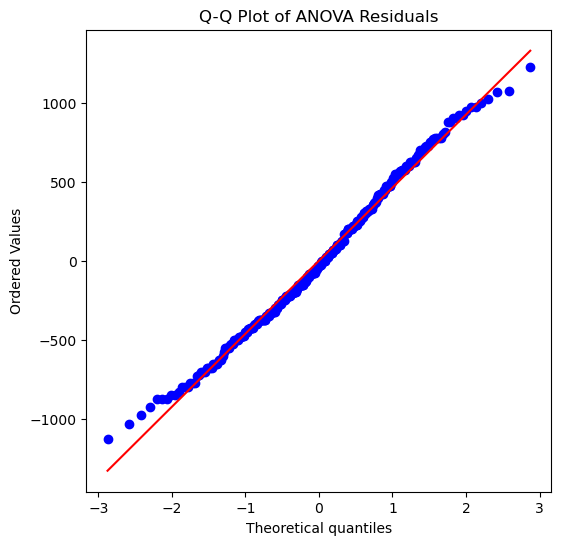

In [7]:
shapiro_adelie = stats.shapiro(adelie)
shapiro_chinstrap = stats.shapiro(chinstrap)
shapiro_gentoo = stats.shapiro(gentoo)

print("Shapiro Adelie:", shapiro_adelie)
print("Shapiro Chinstrap:", shapiro_chinstrap)
print("Shapiro Gentoo:", shapiro_gentoo)

levene_stat, levene_p = stats.levene(adelie, chinstrap, gentoo)

print("Levene statistic:", levene_stat)
print("Levene p-value:", levene_p)

model = ols("body_mass_g ~ C(species)", data=df2).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

residuals = model.resid

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals")
plt.show()

### Assumption Summary

The **Shapiro-Wilk test** checks whether each group is approximately normally distributed.  
If a group's p-value is less than **0.05**, normality may be violated for that group.

The **Levene test** checks whether group variances are equal.  
If the p-value is less than **0.05**, the equal-variance assumption is violated.

The **Q-Q plot** helps visually assess whether the residuals are approximately normal.  
If the points follow the reference line closely, the residuals are roughly normal. If they clearly bend away from the line, normality is not well satisfied.

If assumptions are violated, alternatives include **Welch’s ANOVA** for unequal variances or **Kruskal-Wallis** as a non-parametric alternative.

     Multiple Comparison of Means - Tukey HSD, FWER=0.05      
  group1    group2  meandiff p-adj    lower     upper   reject
--------------------------------------------------------------
   Adelie Chinstrap   32.426 0.8807 -126.5002  191.3522  False
   Adelie    Gentoo 1375.354    0.0 1243.1786 1507.5294   True
Chinstrap    Gentoo 1342.928    0.0  1178.481  1507.375   True
--------------------------------------------------------------
      group1     group2  meandiff   p-adj      lower      upper  reject
0     Adelie  Chinstrap    32.426  0.8807  -126.5002   191.3522   False
1     Adelie     Gentoo  1375.354  0.0000  1243.1786  1507.5294    True
2  Chinstrap     Gentoo  1342.928  0.0000  1178.4810  1507.3750    True


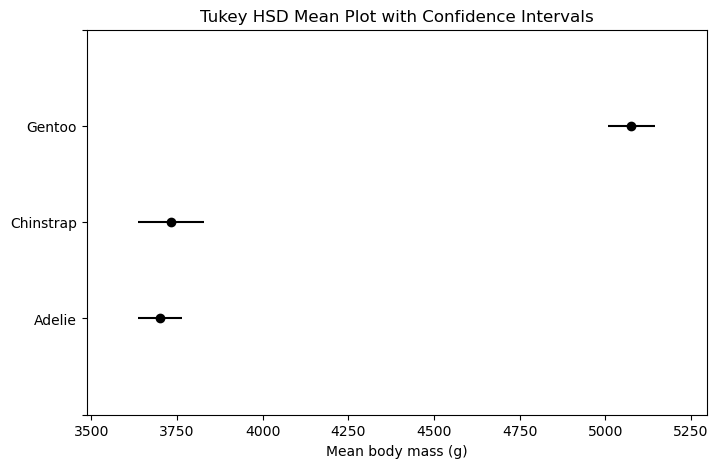

In [8]:
tukey = pairwise_tukeyhsd(
    endog=df2["body_mass_g"],
    groups=df2["species"],
    alpha=0.05
)

print(tukey)

tukey_df = pd.DataFrame(
    tukey.summary().data[1:],
    columns=tukey.summary().data[0]
)

print(tukey_df)


tukey.plot_simultaneous(figsize=(8, 5))
plt.title("Tukey HSD Mean Plot with Confidence Intervals")
plt.xlabel("Mean body mass (g)")
plt.show()


### Tukey HSD Interpretation

The Tukey HSD test compares all pairs of species to determine which means are significantly different.

- If **reject = True**, the pair has significantly different mean body mass.
- If **reject = False**, there is not enough evidence to say the two group means are different.

The **mean difference** shows how far apart the group means are.  
The **confidence interval** gives a reasonable range for that difference.

The confidence intervals also help show the practical size of the difference.  
Pairs with clearly separated intervals usually show a stronger and more meaningful difference.

### Assumption Summary

The residuals do **not** appear to be approximately normal.  
Both the **Q-Q plot** and the **Shapiro-Wilk test** suggest departures from normality, since the points clearly deviate from the reference line and the Shapiro p-values for both groups are much smaller than **0.05**.

The **equal-variance assumption** is also violated, because **Levene’s test p-value = 0.0143**, which is less than **0.05**.

Since one or both ANOVA assumptions are violated, alternative methods may be more appropriate.  
For **two groups**, a **Welch’s t-test** can be used when variances are unequal, and a **Mann-Whitney U test** can be used as a non-parametric alternative if normality is not met.  
For **more than two groups**, alternatives include **Welch’s ANOVA** or the **Kruskal-Wallis test**.

### Tukey HSD Interpretation

There is only **one pairwise comparison** in this analysis: **Male vs Female**.

The **Male and Female groups have significantly different mean body mass**, because the Tukey HSD result indicates a statistically significant difference (**reject = True**).

There are **no pairs that are not significantly different**, since only one pair was tested and that pair was significant.

Yes, the **confidence intervals help** us understand the practical size of the difference.  
The plot shows that the mean body mass for males is clearly higher than for females, and the intervals show the estimated range around each group mean. Since the intervals show little to no overlap, this supports that the difference is not only statistically significant but also practically noticeable.